In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#ensure the path of files is correct for this all to work correctly
from pathlib import Path
print("Notebook running from:", Path.cwd())

# ---- Project paths ----
ROOT = Path("..").resolve()     # one folder up from 'notebooks' → 'BBO'
DATA = ROOT / "data"


print("ROOT:", ROOT)
print("DATA:", DATA)
print("Contents of DATA:", [p.name for p in DATA.iterdir()])

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'function_summary.csv']


In [11]:
# pick which function to inspect
FN = "F3"   # change to F2..F8 later

# --- Read and print the description of the selected function ---
summary_path = DATA / "function_summary.csv" # path to your summary CSV
func_info = pd.read_csv(summary_path) # load it as a DataFrame
match = func_info.loc[func_info["Function"] == FN] # matches your function name (e.g., F1)
description = match["Description"].values[0] # extract the Description text
print(f"{FN} description:")
print(description)

df = pd.DataFrame(
    np.load(DATA / FN / "initial_inputs.npy"),
    columns=[f"x{i+1}" for i in range(np.load(DATA / FN / "initial_inputs.npy").shape[1])]
)
df["y"] = np.load(DATA / FN / "initial_outputs.npy")

display(df.head())
display(df.describe())

xs = [c for c in df.columns if c.startswith("x")]
summary = {
    "rows": len(df),
    "dims": len(xs),
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in xs},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
summary


F3 description:
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008


,x1,x2,x3,y
count,16.000000,16.000000,16.000000,16.000000
mean,0.383467,0.485322,0.377613,-0.111887
std,0.284711,0.259610,0.292393,0.086305
min,0.000000,0.000000,0.000000,-0.398926
25%,0.165817,0.294418,0.213072,-0.114913
50%,0.293819,0.419246,0.270898,-0.108293
75%,0.611449,0.678247,0.485362,-0.054571
max,0.965995,0.941360,0.990882,-0.034835


{'rows': 16,
 'dims': 3,
 'bounds': {'x1': (0.0, 0.9659948489488087),
  'x2': (0.0, 0.9413598305723256),
  'x3': (0.0, 0.990881866558951)},
 'y_min': -0.3989255131463011,
 'y_max': -0.034835313350078584}

In [12]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


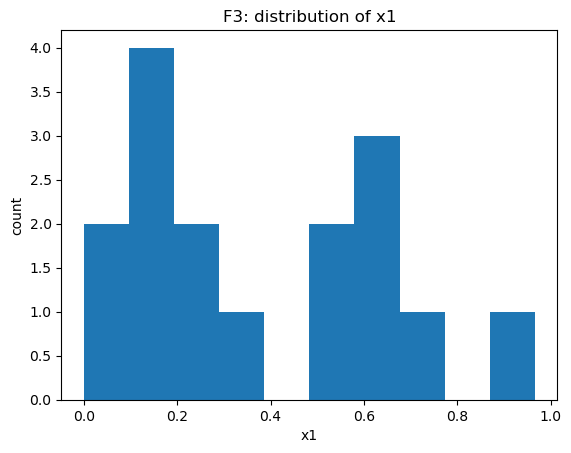

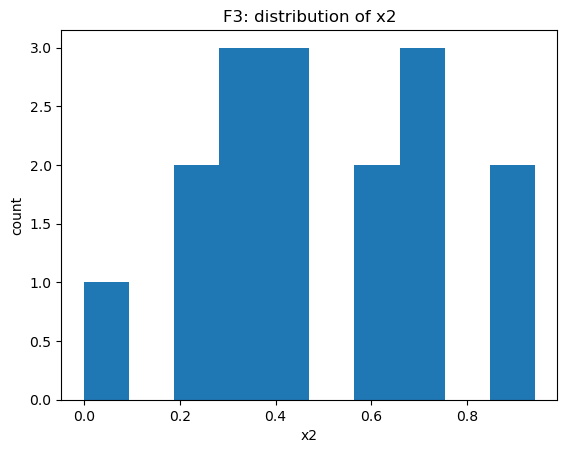

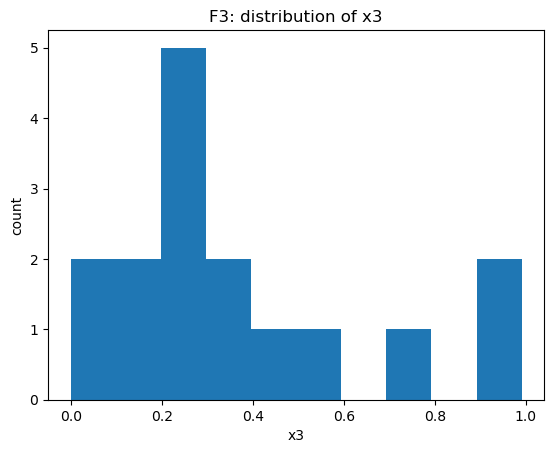

In [13]:
#Simple plot to see the points
xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

if d == 1:
    plt.figure()
    plt.scatter(df[xs[0]], df["y"])
    plt.xlabel(xs[0]); plt.ylabel("y"); plt.title(f"{FN}: y vs {xs[0]}")
    plt.show()

elif d == 2:
    plt.figure()
    sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"])
    plt.xlabel(xs[0]); plt.ylabel(xs[1]); plt.title(f"{FN}: inputs colored by y")
    plt.colorbar(sc, label="y")
    plt.show()

else:
    # higher-D: show simple histograms so you see ranges
    for c in xs:
        plt.figure()
        plt.hist(df[c], bins=10)
        plt.xlabel(c); plt.ylabel("count"); plt.title(f"{FN}: distribution of {c}")
        plt.show()


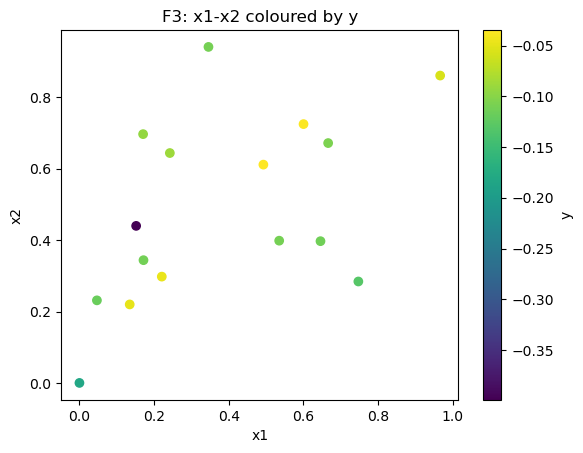

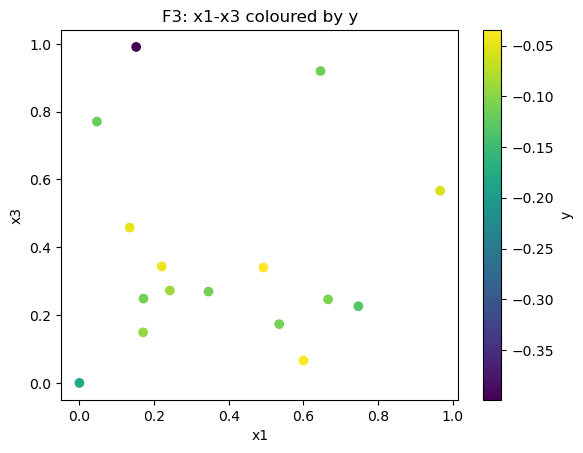

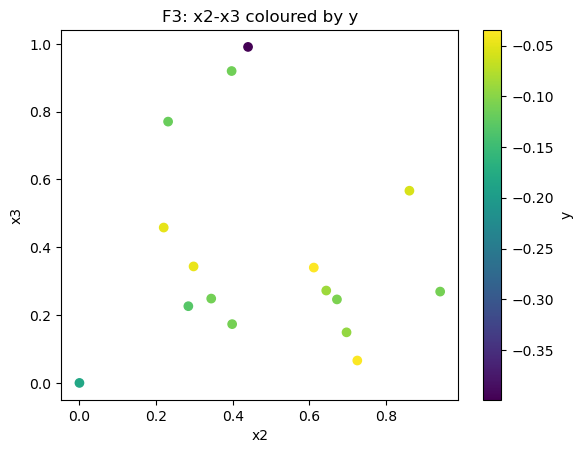

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df["x1"], df["x2"], c=df["y"], cmap="viridis")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F3: x1-x2 coloured by y")
plt.colorbar(label="y")
plt.show()

import matplotlib.pyplot as plt

plt.scatter(df["x1"], df["x3"], c=df["y"], cmap="viridis")
plt.xlabel("x1")
plt.ylabel("x3")
plt.title("F3: x1-x3 coloured by y")
plt.colorbar(label="y")
plt.show()

import matplotlib.pyplot as plt

plt.scatter(df["x2"], df["x3"], c=df["y"], cmap="viridis")
plt.xlabel("x2")
plt.ylabel("x3")
plt.title("F3: x2-x3 coloured by y")
plt.colorbar(label="y")
plt.show()


In [15]:
df.corr(numeric_only=True)["y"].sort_values(ascending=False)

y     1.000000
x1    0.306796
x2    0.243084
x3   -0.450191
Name: y, dtype: float64

Text(0, 0.5, 'x3')

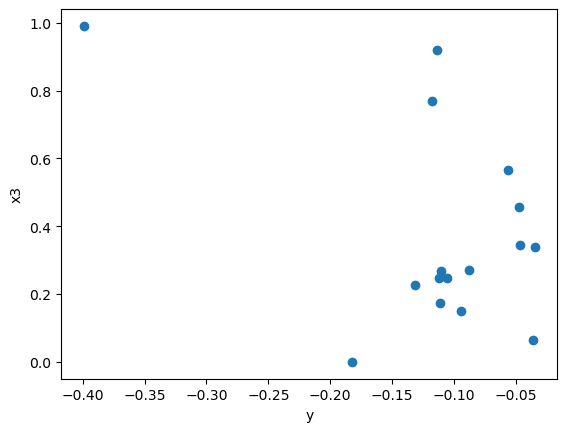

In [16]:
plt.scatter(df["y"], df["x3"])
plt.xlabel("y")
plt.ylabel("x3")


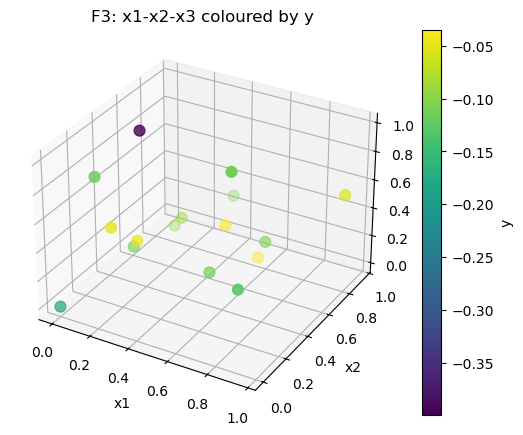

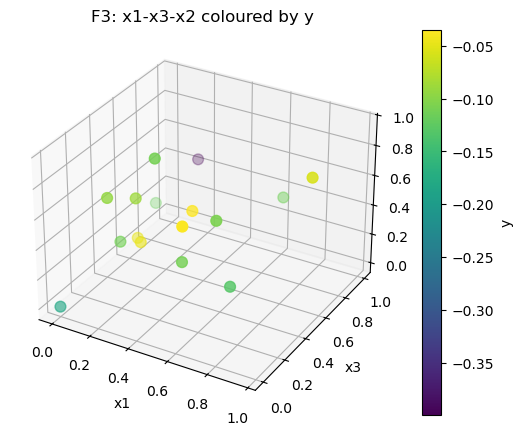

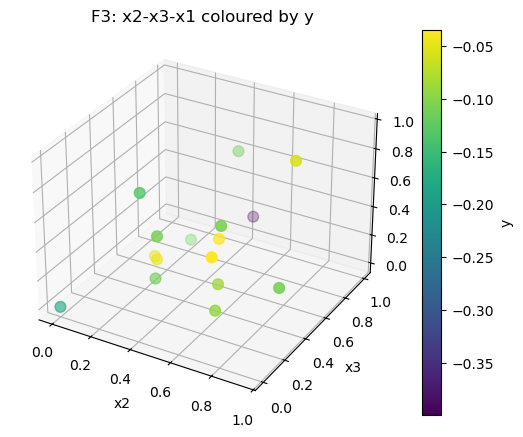

In [17]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def plot_3d_combo(x, y, z, df, FN):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(df[x], df[y], df[z], c=df["y"], cmap="viridis", s=60)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    ax.set_title(f"{FN}: {x}-{y}-{z} coloured by y")
    plt.colorbar(sc, label="y")
    plt.show()

# Try different "views"
plot_3d_combo("x1", "x2", "x3", df, FN)
plot_3d_combo("x1", "x3", "x2", df, FN)
plot_3d_combo("x2", "x3", "x1", df, FN)


In [18]:
# === FINAL EI MINIMIZATION BLOCK FOR FUNCTION 3 ================================
import numpy as np
import pandas as pd

# --- Helper: safe normal PDF/CDF without requiring SciPy
def _std_norm_pdf(z):
    z = np.asarray(z, dtype=float)
    return np.exp(-0.5 * z*z) / np.sqrt(2.0*np.pi)

def _std_norm_cdf(z):
    # Abramowitz–Stegun erf-based approx via numpy
    # cdf = 0.5 * [1 + erf(z / sqrt(2))]
    from math import erf, sqrt
    z = np.asarray(z, dtype=float)
    return 0.5 * (1.0 + np.vectorize(erf)(z/np.sqrt(2.0)))

def expected_improvement_min(mu, sd, y_best, xi=0.01):
    """EI for *minimization* with numerical guards."""
    mu = np.asarray(mu, dtype=float).reshape(-1)
    sd = np.asarray(sd, dtype=float).reshape(-1)
    imp = (y_best - mu - xi)
    Z = np.divide(imp, sd, out=np.zeros_like(imp), where=sd > 1e-12)
    return imp * _std_norm_cdf(Z) + sd * _std_norm_pdf(Z)

# --- Helper: simple min distance to existing points (no SciPy needed)
def min_dist_to_set(x, X):
    if X is None or len(X) == 0:
        return np.inf
    # broadcasting pairwise distances
    d = np.linalg.norm(X - x, axis=1)
    return float(np.min(d))

# --- Inputs expected to exist from earlier cells:
# X (n,d), y (n,), gp (fitted), G (m,d) candidate grid, Xcols (list of names)
# If G wasn’t built yet, create a dense grid on [0,1]^d (fallback).
d = X.shape[1]
try:
    G  # noqa
except NameError:
    g = np.linspace(0.0, 1.0, 201)
    if d == 1:
        G = g.reshape(-1,1)
    else:
        mesh = np.meshgrid(*([g]*d), indexing="xy")
        G = np.stack([m.ravel() for m in mesh], axis=1)

# Optional: if you maintain explicit portal bounds, use them here
# Example structure: portal_bounds = {"x1": (0.0,1.0), "x2": (0.0,1.0), ...}
try:
    portal_bounds  # noqa
    # Clamp G to portal bounds if dict present and Xcols provided
    if 'Xcols' in globals() and len(Xcols) == d:
        lo = np.array([portal_bounds[c][0] for c in Xcols], dtype=float)
        hi = np.array([portal_bounds[c][1] for c in Xcols], dtype=float)
        G = np.clip(G, lo, hi)
except NameError:
    pass

# --- GP predictions
mu, sd = gp.predict(G, return_std=True)
y_best = float(np.min(y))
xi = 0.01  # small exploration boost

EI = expected_improvement_min(mu, sd, y_best, xi=xi)

# --- Diversity filter (optional but recommended)
# skip any candidate too close to an existing point
min_dist = 0.01  # tweak if your inputs are not on [0,1]
mask_far = np.array([min_dist_to_set(G[i], X) >= min_dist for i in range(len(G))])
if np.any(mask_far):
    cand_idx = np.argmax(EI * mask_far)  # masked EI; zeros where too close
else:
    cand_idx = int(np.argmax(EI))

x_next = G[cand_idx]
mu_next = float(mu[cand_idx])
sd_next = float(sd[cand_idx])
ei_next = float(EI[cand_idx])
mindist_next = min_dist_to_set(x_next, X)

# --- Pretty print + table
print("\n" + "="*70)
print("Function 3 — RECOMMENDED NEXT POINT")
print("="*70)
print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi={xi}): predicted mean={mu_next:.4f}, std={sd_next:.4f}, EI={ei_next:.4f}")
print(f"Min distance from existing points: {mindist_next:.3f}")

# Column names, if available
if 'Xcols' in globals() and len(Xcols) == d:
    x_next_df = pd.DataFrame([x_next], columns=Xcols).round(6)
else:
    Xcols = [f"x{i+1}" for i in range(d)]
    x_next_df = pd.DataFrame([x_next], columns=Xcols).round(6)

try:
    display(x_next_df.style.set_caption("🚀 Recommended query to submit this week"))
except Exception:
    print("\nRecommended query:")
    print(x_next_df)

print("="*70)
print("Copy these values into the Capstone submission portal for this week's query.")
print("="*70)

# --- Persist the pick (nice for weekly tracking)
try:
    pick_row = x_next_df.copy()
    pick_row["y_best_so_far"] = y_best
    pick_row["mu_pred"] = mu_next
    pick_row["sd_pred"] = sd_next
    pick_row["EI"] = ei_next
    pick_row["mindist"] = mindist_next
    pick_row["function"] = "F3"
    pick_row["week_tag"] = pd.Timestamp.now().strftime("%Y-%m-%d_%H%M")
    pick_row.to_csv("f3_picks_history.csv", mode="a", header=not os.path.exists("f3_picks_history.csv"), index=False)
    print("Saved append to f3_picks_history.csv")
except Exception as e:
    print("Could not persist pick:", e)
# ==============================================================================


NameError: name 'X' is not defined